# Phase 1: Exploratory Data Analysis (EDA) & Clinical Feature Profiling

In this notebook, we conduct a comprehensive Exploratory Data Analysis (EDA) on the Heart Disease dataset. The objective is to understand the underlying distributions of our 11 clinical features (6 numerical, 5 categorical) and their statistical relationships with the target variable (`HeartDisease`). 

This rigorous profiling ensures our downstream preprocessing pipeline and machine learning models are built on validated data assumptions.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration for production-grade plots
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
sns.set_palette("muted")

# Load the raw dataset
data_path = '../data/raw/heart.csv'
df = pd.read_csv(data_path, sep='\t')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
display(df.head())

Dataset Shape: 918 rows, 12 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 1. Data Integrity & Descriptive Statistics
Before visualizing, we must verify data integrity (missing values, data types) and observe the statistical summary of our numerical features.

In [8]:
# Check for missing values and data types
display(df.info())

# Statistical summary of numerical features
display(df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


None

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


## 2. Target Variable Distribution
Understanding the class balance is critical. An imbalanced target requires specific handling (e.g., SMOTE or class weights) during the modeling phase.

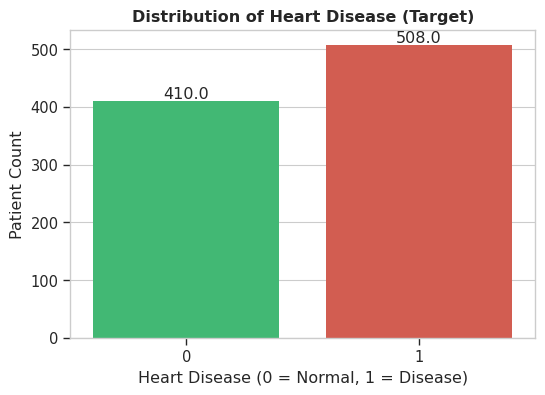

In [9]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='HeartDisease', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Heart Disease (Target)', weight='bold')
plt.xlabel('Heart Disease (0 = Normal, 1 = Disease)')
plt.ylabel('Patient Count')

# Annotate counts
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

## 3. Categorical Features vs. Target
We analyze how categorical clinical metrics (e.g., Chest Pain Type, ST Slope) correlate with the presence of heart disease.

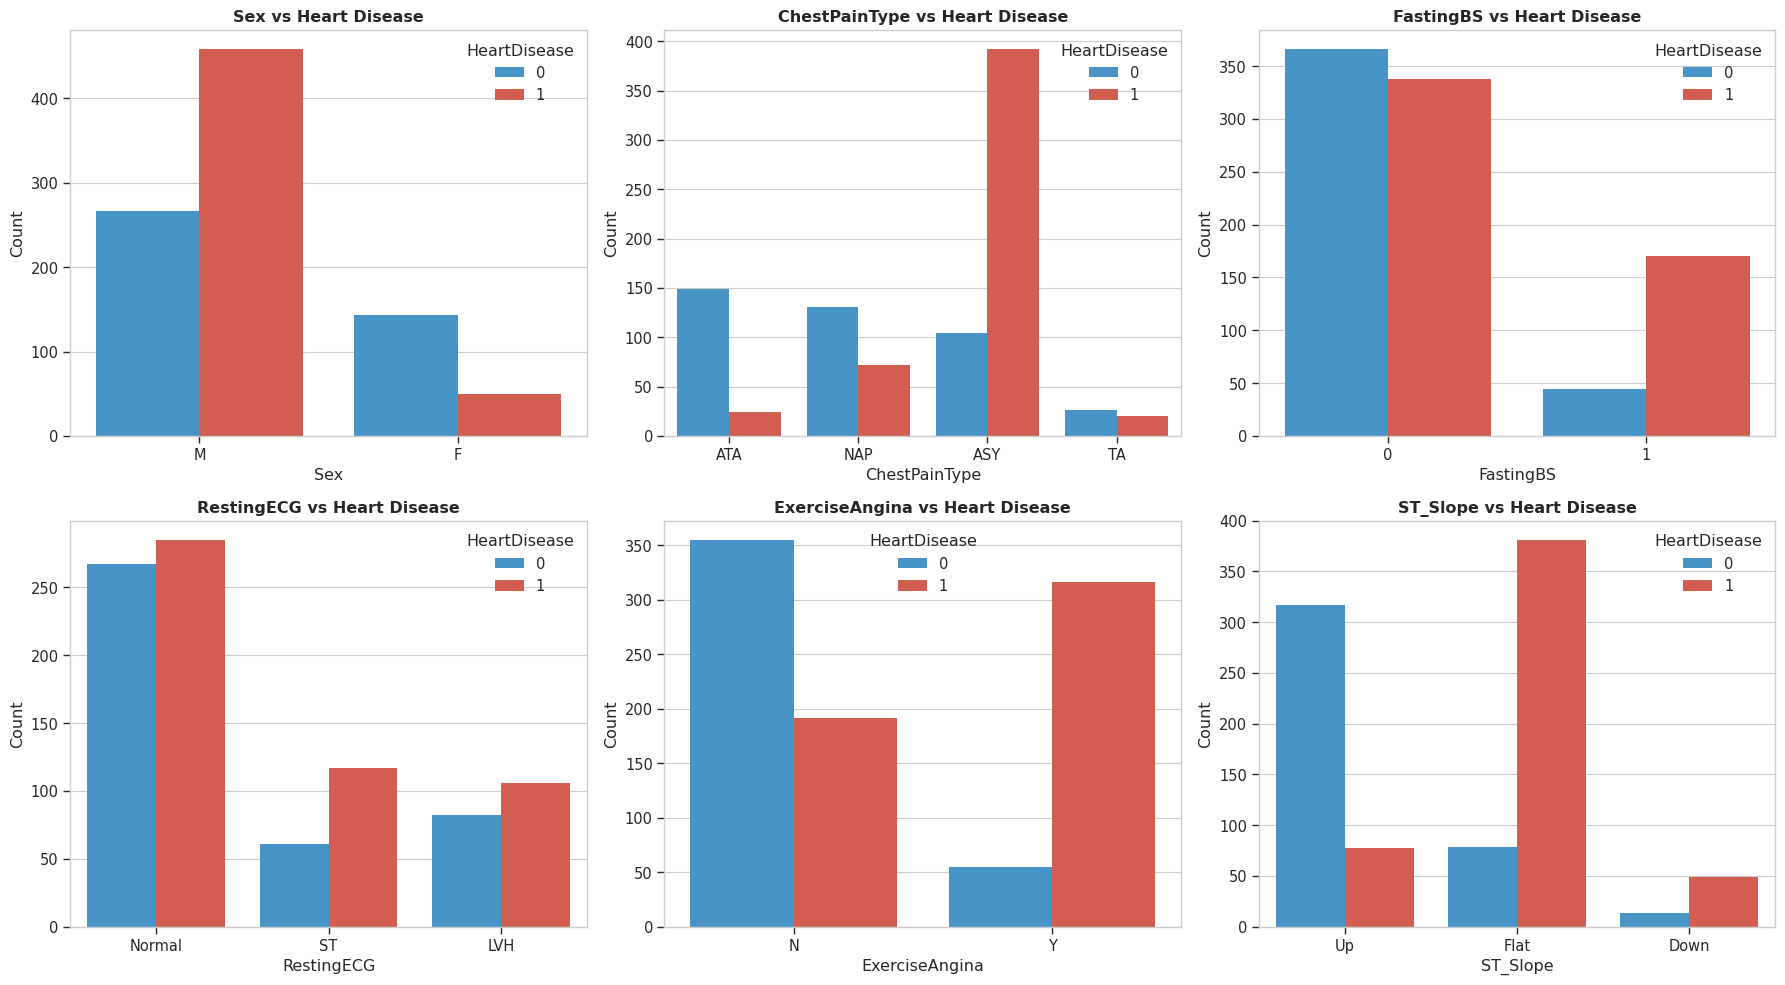

In [10]:
categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} vs Heart Disease', weight='bold')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Numerical Features: Distributions & Correlations
We utilize a correlation heatmap to detect multicollinearity among numerical features, and boxplots to observe how numerical distributions shift between healthy and diseased patients.

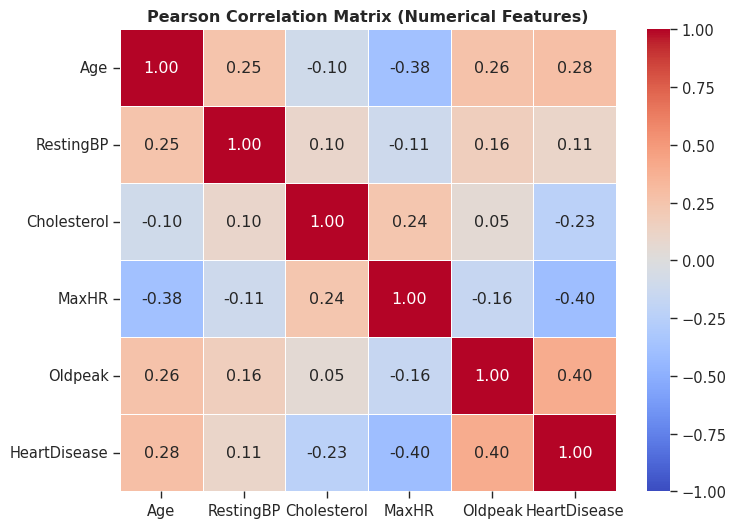

In [11]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Correlation Heatmap
plt.figure(figsize=(8, 6))
corr_matrix = df[numeric_cols + ['HeartDisease']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix (Numerical Features)', weight='bold')
plt.show()

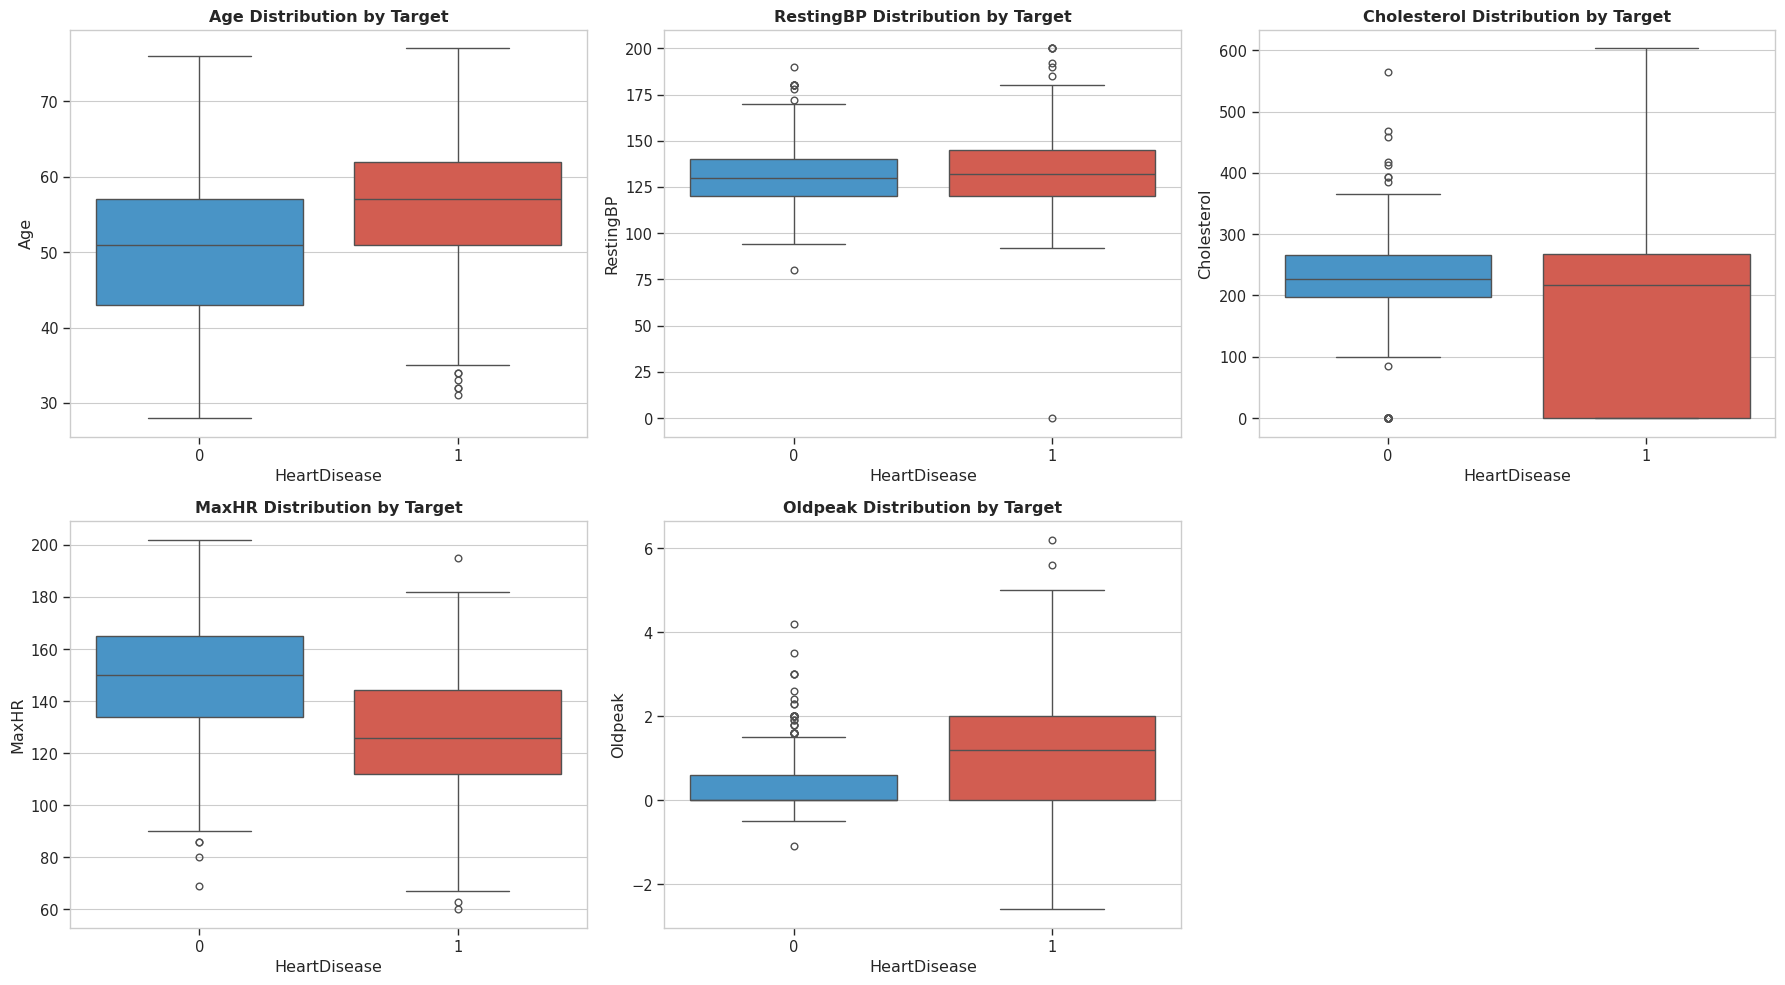

In [12]:
# Boxplots for numerical features against the target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='HeartDisease', y=col, ax=axes[i], palette=['#3498db', '#e74c3c'])
    axes[i].set_title(f'{col} Distribution by Target', weight='bold')

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 5. Clinical Anomalies & Advanced Data Imputation (MCAR)

**Clinical Observation from EDA:**
Upon reviewing the numerical distributions, a critical physiological anomaly is present: `RestingBP` and `Cholesterol` contain minimum values of `0`. In a living patient, a blood pressure or total cholesterol of 0 is physiologically impossible. This indicates that 0 was used as a placeholder for missing data (Missing Completely At Random - MCAR).

**Imputation Strategy:**
Replacing these values with a global Median would distort the statistical variance and ignore patient-specific clinical profiles. Instead, we employ a **K-Nearest Neighbors (KNN) Imputer**. By calculating the Euclidean distance across other numerical features (like Age and MaxHR), KNN estimates the missing cholesterol/BP based on the top 5 clinically similar patients, preserving the multidimensional variance.

In [13]:
from sklearn.impute import KNNImputer

# 1. Isolate anomalies and replace 0 with NaN for imputation
df_cleaned = df.copy()
df_cleaned['RestingBP'] = df_cleaned['RestingBP'].replace(0, np.nan)
df_cleaned['Cholesterol'] = df_cleaned['Cholesterol'].replace(0, np.nan)

# 2. Isolate numeric columns for distance calculations (KNN requires numeric data)
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_numeric = df_cleaned[numeric_features]

# 3. Apply KNN Imputation (k=5, distance-weighted)
imputer = KNNImputer(n_neighbors=5, weights='distance')
df_numeric_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric), 
    columns=numeric_features, 
    index=df_cleaned.index
)

# 4. Reintegrate imputed numerical data back into the main dataset
df_cleaned[numeric_features] = df_numeric_imputed

print("Missing values after KNN Imputation:")
print(df_cleaned[['RestingBP', 'Cholesterol']].isnull().sum())

Missing values after KNN Imputation:
RestingBP      0
Cholesterol    0
dtype: int64


## 6. Visual Proof of Variance Preservation
To validate our imputation strategy, we compare the original distribution (excluding 0s) with the newly imputed distribution. A successful KNN imputation should smoothly fill the gaps without creating artificial spikes (which is a common flaw in Mean/Median imputation).

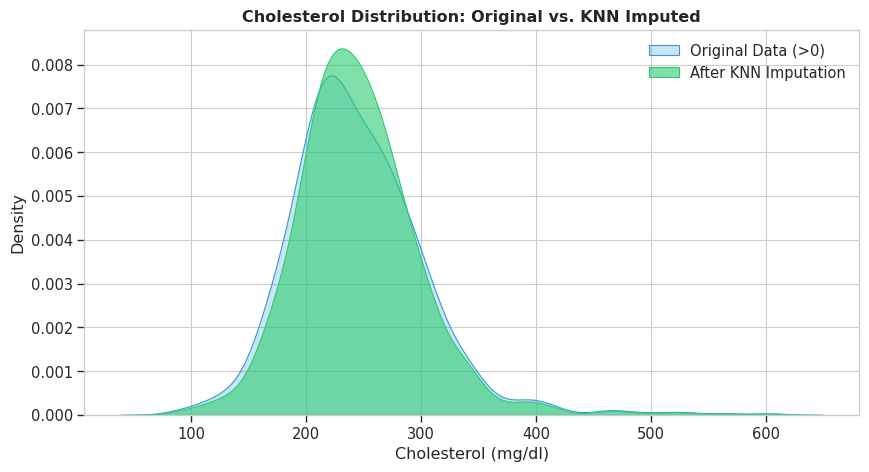

In [14]:
# Visual Validation: Original vs. Imputed Cholesterol Distribution
plt.figure(figsize=(10, 5))

# Original Distribution (Filtering out 0s)
sns.kdeplot(df['Cholesterol'][df['Cholesterol'] > 0], fill=True, color='#3498db', label='Original Data (>0)')

# Imputed Distribution
sns.kdeplot(df_cleaned['Cholesterol'], fill=True, color='#2ecc71', alpha=0.6, label='After KNN Imputation')

plt.title('Cholesterol Distribution: Original vs. KNN Imputed', weight='bold')
plt.xlabel('Cholesterol (mg/dl)')
plt.ylabel('Density')
plt.legend()
plt.show()